### ESAM 495 Assignment 5: Quasi-Steady State Analysis & Thermodynamics

Author: Phoebe Kuang

Date: June 5, 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# GaAs Parameters 
q = 1.602e-19       # Elementary charge (C)
kT = 0.0259         # Thermal energy at 300K (eV)
eps_0 = 8.854e-14   # Vacuum permittivity (F/cm)
eps_r = 13.1        # Relative permittivity of GaAs
eps_s = eps_r * eps_0

Eg = 1.42           # Bandgap of GaAs (eV)
ni = 2.35e6         # Intrinsic carrier conc. (cm^-3)
Nc = 4.45e17        # Effective density of states, Cond. Band (cm^-3)
Nv = 8.87e18        # Effective density of states, Val. Band (cm^-3)

Na = 1e17           # p-type doping (cm^-3)
Nd = 1e16           # n-type doping (cm^-3)

xp = 1e-4           # p-region width: 1 um = 1e-4 cm
xn = 2e-4           # n-region width: 2 um = 2e-4 cm

Ln = 1e-4           # Electron diffusion length (cm)
Lp = 1e-4           # Hole diffusion length (cm)
Dn = 228.0          # Electron diffusion coeff (cm^2/s)
Dp = 10.0           # Hole diffusion coeff (cm^2/s)
Sn = 0.0            # Front surface recombination velocity (cm/s)
Sp = 0.0            # Back surface recombination velocity (cm/s)
v_sat = 1.2e7       # Saturation velocity (cm/s)

# Illumination Parameters
alpha = 2.5e4        # Effective absorption coefficient (cm^-1)
bs = 1.8e17           # Effective total integrated photon flux (cm^-2 s^-1)
R = 0.0              # Reflectivity

In [3]:
def plot_solar_cell(V_app, illumination=False, title=""):
    
    # Electrostatics (Depletion Widths)
    Vbi = kT * np.log((Na * Nd) / ni**2)
    V_j = Vbi - V_app  # Net barrier height
    
    W = np.sqrt((2 * eps_s / q) * (1/Na + 1/Nd) * V_j)
    wp = W * (Nd / (Na + Nd))
    wn = W * (Na / (Na + Nd))
    
    # Light Generation Terms
    if illumination:
        gn = -alpha * (1 - R) * bs * Ln**2 / (Dn * (alpha**2 * Ln**2 - 1))
        gp = -alpha * (1 - R) * bs * Lp**2 / (Dp * (alpha**2 * Lp**2 - 1))
    else:
        gn, gp = 0.0, 0.0

    # Minority Carrier Analytical Constants
    # Electrons in p-region
    n0 = ni**2 / Na
    up = (xp - wp) / Ln
    An = n0 * (np.exp(V_app/kT) - 1) - gn * np.exp(-alpha*(xp - wp))
    denom_n = (Sn*Ln/Dn)*np.sinh(up) + np.cosh(up)
    term1_n = gn * (np.exp(-alpha*(xp-wp)) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up)) - (Sn*Ln/Dn + alpha*Ln))
    term2_n = n0 * (np.exp(V_app/kT) - 1) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up))
    Bn = (term1_n - term2_n) / denom_n

    # Holes in n-region
    p0 = ni**2 / Nd
    un = (xn - wn) / Lp
    Ap = p0 * (np.exp(V_app/kT) - 1) - gp * np.exp(-alpha*(xp + wn))
    denom_p = (Sp*Lp/Dp)*np.sinh(un) + np.cosh(un)
    term1_p = p0 * (np.exp(V_app/kT) - 1) * ((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un))
    term2_p = gp * np.exp(-alpha*(xp+wn)) * (((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un)) - (Sp*Lp/Dp - alpha*Lp)*np.exp(-alpha*(xn-wn)))
    Bp = (term1_p - term2_p) / denom_p

    # Setup Spatial Grid
    x_p = np.linspace(-xp, -wp, 300)
    x_scr = np.linspace(-wp, wn, 300)
    x_n = np.linspace(wn, xn, 300)

    # Calculate Carrier Concentrations
    n_p = An*np.cosh((-x_p - wp)/Ln) + Bn*np.sinh((-x_p - wp)/Ln) + gn*np.exp(-alpha*(x_p + xp)) + n0
    p_p = np.full_like(x_p, Na)

    p_n = Ap*np.cosh((-x_n + wn)/Lp) + Bp*np.sinh((-x_n + wn)/Lp) + gp*np.exp(-alpha*(x_n + xp)) + p0
    n_n = np.full_like(x_n, Nd)

    # Calculate Potentials & Band Edges
    # Set the Hole Quasi-Fermi level in the p-region to 0 eV as the absolute reference
    EFp_p_val = 0.0
    EFn_n_val = V_app
    
    # Establish Ev and Ec in the neutral p-region
    Ev_p_val = EFp_p_val - kT * np.log(Nv / Na)
    Ec_p_val = Ev_p_val + Eg
    
    # Establish Ev and Ec in the neutral n-region
    Ec_n_val = EFn_n_val + kT * np.log(Nc / Nd)
    Ev_n_val = Ec_n_val - Eg

    # Quadratic band bending in the SCR
    Ev_p = np.full_like(x_p, Ev_p_val)
    Ev_scr = np.where(x_scr < 0, 
                      Ev_p_val - (q * Na / (2 * eps_s)) * (x_scr + wp)**2,
                      Ev_n_val + (q * Nd / (2 * eps_s)) * (x_scr - wn)**2)
    Ev_n = np.full_like(x_n, Ev_n_val)

    Ec_p = np.full_like(x_p, Ec_p_val)
    Ec_scr = Ev_scr + Eg
    Ec_n = np.full_like(x_n, Ec_n_val)

    # SCR Carriers (Assumes constant quasi-Fermi levels across depletion region)
    EFp_scr_val = EFp_p_val
    EFn_scr_val = EFn_n_val
    n_scr = Nc * np.exp(-(Ec_scr - EFn_scr_val) / kT)
    p_scr = Nv * np.exp(-(EFp_scr_val - Ev_scr) / kT)

    # Calculate Quasi-Fermi Levels in Neutral Regions
    safe_n_p = np.maximum(n_p, 1e-30)
    safe_p_n = np.maximum(p_n, 1e-30)
    
    EFn_p = Ec_p - kT * np.log(Nc / safe_n_p)
    EFp_n = Ev_n + kT * np.log(Nv / safe_p_n)

    # Combine All Regions for Plotting
    X_full = np.concatenate([x_p, x_scr, x_n]) * 1e4 + 1.0 
    
    Ec_full = np.concatenate([Ec_p, Ec_scr, Ec_n])
    Ev_full = np.concatenate([Ev_p, Ev_scr, Ev_n])
    
    EFn_full = np.concatenate([EFn_p, np.full_like(x_scr, EFn_scr_val), np.full_like(x_n, EFn_n_val)])
    EFp_full = np.concatenate([np.full_like(x_p, EFp_p_val), np.full_like(x_scr, EFp_scr_val), EFp_n])

    n_full = np.concatenate([n_p, n_scr, n_n])
    p_full = np.concatenate([p_p, p_scr, p_n])

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(title, fontsize=16)

    # Left Panel: Energy Bands
    ax1.plot(X_full, Ec_full, color='#008080', lw=2, label='$E_c$')
    ax1.plot(X_full, Ev_full, color='#800000', lw=2, label='$E_v$')
    
    if not illumination and V_app == 0:
        ax1.plot(X_full, EFn_full, 'gray', ls='--', lw=2, label='$E_{Fn} = E_{Fp}$')
    else:
        ax1.plot(X_full, EFn_full, 'b--', lw=2, label='$E_{Fn}$')
        ax1.plot(X_full, EFp_full, 'r--', lw=2, label='$E_{Fp}$')

    ax1.set_ylabel('Energy / eV', fontsize=16)
    ax1.set_xlabel(r'Distance / $\mu$m', fontsize=16)
    ax1.set_ylim(-1.5, 1.5)
    ax1.set_xlim(0, 3)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Right Panel: Carrier Densities
    ax2.semilogy(X_full, np.maximum(p_full, 1e-5), 'b-', lw=2, label='p')
    ax2.semilogy(X_full, np.maximum(n_full, 1e-5), 'r-', lw=2, label='n')
    ax2.set_ylabel(r'Carrier density / cm$^{-3}$', fontsize=16)
    ax2.set_xlabel(r'Distance / $\mu$m', fontsize=16)
    ax2.set_ylim(1e-5, 1e18)
    ax2.set_xlim(0, 3)
    ax2.grid(alpha=0.3)
    
    ax2.text(0.5, 1e15, 'p', fontsize=18)
    ax2.text(2.0, 1e15, 'n', fontsize=18)
    ax2.legend()

    plt.tight_layout()
    plt.show()

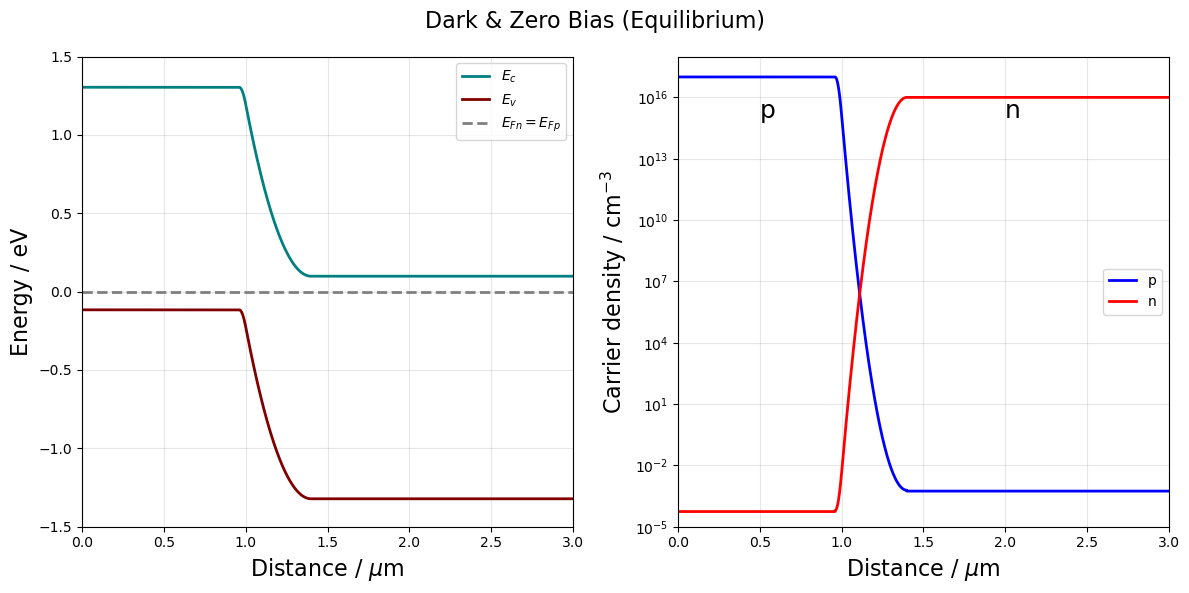

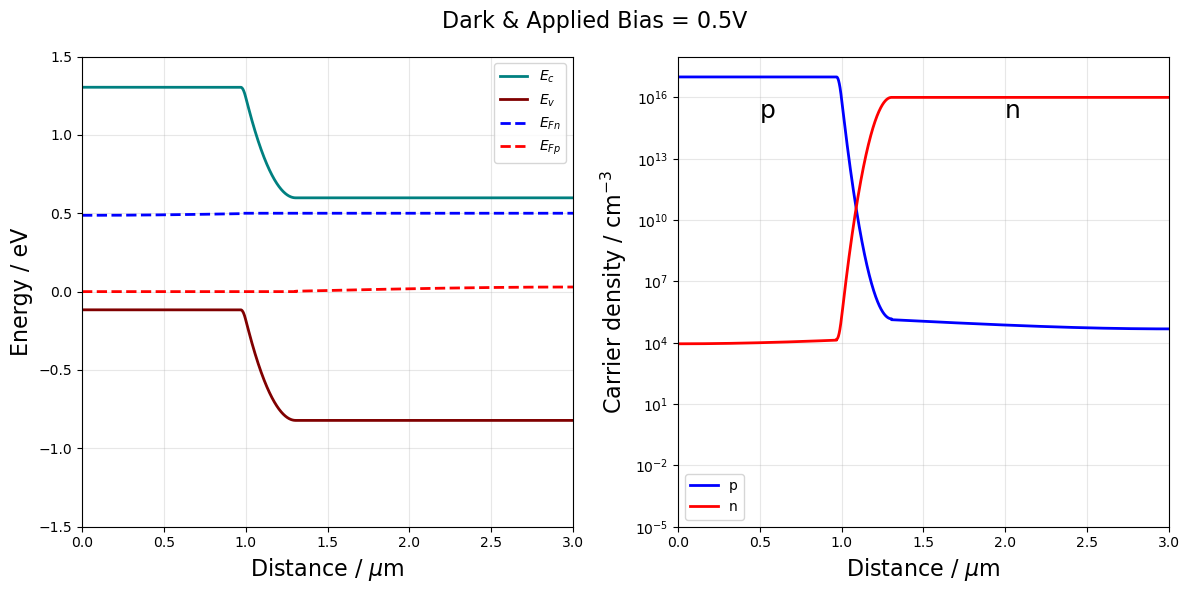

In [4]:
plot_solar_cell(V_app=0.0, illumination=False, title="Dark & Zero Bias (Equilibrium)")
plot_solar_cell(V_app=0.5, illumination=False, title="Dark & Applied Bias = 0.5V")

In [5]:
# Unphysical usage - V should account for both illumination and applied bias
# plot_solar_cell(V_app=0.0, illumination=True, title="Illuminated & Zero Bias (Short Circuit)")
# plot_solar_cell(V_app=0.5, illumination=True, title="Illuminated & Applied Bias = 0.5V")

In [6]:
# Extract Lifetimes from Diffusion Lengths (L = sqrt(D * tau))
tau_n = (Ln**2) / Dn
tau_p = (Lp**2) / Dp

# Current Calculation
def calculate_currents(V):
    Vbi = kT * np.log((Na * Nd) / ni**2)
        
    V_j = Vbi - V
    W = np.sqrt((2 * eps_s / q) * (1/Na + 1/Nd) * V_j)
    wp = W * (Nd / (Na + Nd))
    wn = W * (Na / (Na + Nd))
    
    # Illumination Constants
    gn = -alpha * (1 - R) * bs * Ln**2 / (Dn * (alpha**2 * Ln**2 - 1))
    gp = -alpha * (1 - R) * bs * Lp**2 / (Dp * (alpha**2 * Lp**2 - 1))
    
    # Electron Boundary (p-region)
    n0 = ni**2 / Na
    up = (xp - wp) / Ln
    denom_n = (Sn*Ln/Dn)*np.sinh(up) + np.cosh(up)
    term1_n = gn * (np.exp(-alpha*(xp-wp)) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up)) - (Sn*Ln/Dn + alpha*Ln))
    term2_n = n0 * (np.exp(V/kT) - 1) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up))
    Bn = (term1_n - term2_n) / denom_n
    
    J_n_wp = -q * Dn * ((Bn / Ln) + alpha * gn * np.exp(-alpha * (xp - wp)))
    
    # Hole Boundary (n-region)
    p0 = ni**2 / Nd
    un = (xn - wn) / Lp
    denom_p = (Sp*Lp/Dp)*np.sinh(un) + np.cosh(un)
    term1_p = p0 * (np.exp(V/kT) - 1) * ((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un))
    term2_p = gp * np.exp(-alpha*(xp+wn)) * (((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un)) - (Sp*Lp/Dp - alpha*Lp)*np.exp(-alpha*(xn-wn)))
    Bp = (term1_p - term2_p) / denom_p
    
    J_p_wn = q * Dp * ((Bp / Lp) + alpha * gp * np.exp(-alpha * (xn + wp))) # Note: shifted xn+wp due to coord system
    
    # SCR Current
    # Recombination Term
    J_scr_rec = (q * ni * W) / np.sqrt(tau_n * tau_p) * (2 * np.sinh(V / (2*kT))) / (V_j / kT) * (np.pi / 2)
    # Generation Term
    J_scr_gen = q * (1 - R) * bs * np.exp(-alpha*(xp - wp)) * (1 - np.exp(-alpha * W))
    
    J_scr_total = J_scr_rec - J_scr_gen
    
    # Total Current Superposition
    # Eq: J = -J_n(-wp) - J_p(wn) - J_scr
    J_total = -J_n_wp - J_p_wn - J_scr_total
    
    return J_total

In [7]:
# Simulation (Sweep V)

# Voltage Sweep (0 to 1.05 V)
voltages = np.linspace(0, 1.05, 200)
J_total_A_cm2 = np.array([calculate_currents(V) for V in voltages])

# Convert to mA/cm^2
J_mA = J_total_A_cm2 * 1000
P_mW = J_mA * voltages

# Extract Metrics
J_sc = J_mA[0]
V_oc = np.interp(0, J_mA[::-1], voltages[::-1]) # Find V where J = 0
P_max = np.max(P_mW)
V_mp = voltages[np.argmax(P_mW)]
J_mp = J_mA[np.argmax(P_mW)]
FF = (P_max) / (J_sc * V_oc) * 100

print(f"Solar Cell Device Performance")
print(f"J_sc  = {J_sc:.2f} mA/cm^2")
print(f"V_oc  = {V_oc:.3f} V")
print(f"V_mpp = {V_mp:.3f} V")
print(f"J_mpp = {J_mp:.2f} mA/cm^2")
print(f"P_max = {P_max:.2f} mW/cm^2")
print(f"FF    = {FF:.1f} %")

Solar Cell Device Performance
J_sc  = 20.45 mA/cm^2
V_oc  = 0.790 V
V_mpp = 0.660 V
J_mpp = 18.44 mA/cm^2
P_max = 12.16 mW/cm^2
FF    = 75.3 %


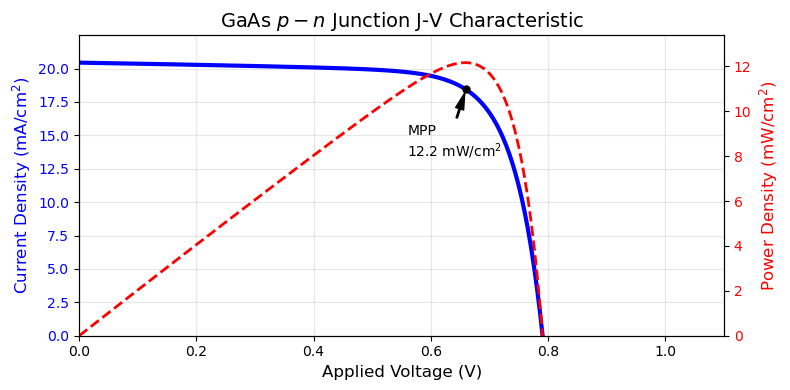

In [8]:
# Plotting (J-V Curve)
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot J-V Curve
ax1.plot(voltages, J_mA, 'b-', lw=3, label='J-V Curve')
ax1.set_xlabel('Applied Voltage (V)', fontsize=12)
ax1.set_ylabel(r'Current Density (mA/cm$^2$)', fontsize=12, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlim(0, 1.1)
ax1.set_ylim(0, J_sc * 1.1)
ax1.grid(alpha=0.3)

# Plot Power Curve
ax2 = ax1.twinx()
ax2.plot(voltages, P_mW, 'r--', lw=2, label='Power Curve')
ax2.set_ylabel(r'Power Density (mW/cm$^2$)', fontsize=12, color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, P_max * 1.1)

# Annotate Maximum Power Point
ax1.plot(V_mp, J_mp, 'ko', markersize=5)
ax1.annotate(f'MPP\n{P_max:.1f} mW/cm$^2$', xy=(V_mp, J_mp), xytext=(V_mp-0.1, J_mp-5),
             arrowprops=dict(facecolor='black', shrink=0.1, width=1, headwidth=6))

plt.title("GaAs $p-n$ Junction J-V Characteristic", fontsize=14)
fig.tight_layout()
plt.show()

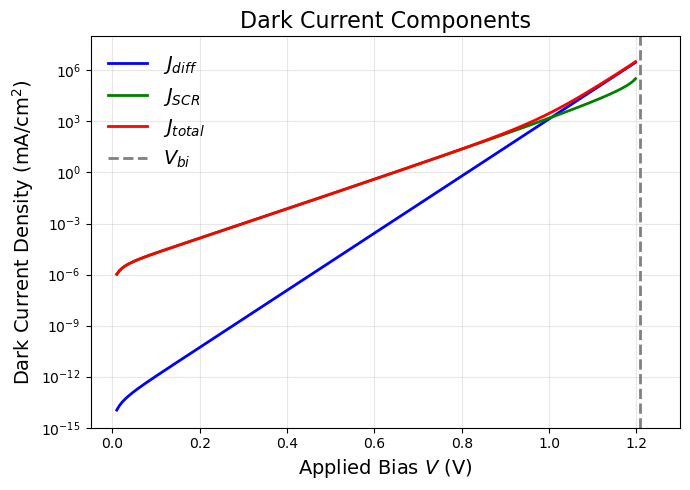

In [9]:
def calculate_current_components(V_app):
    """Calculates J_diff and J_SCR specifically for the dark case."""
    Vbi = kT * np.log((Na * Nd) / ni**2)
    V_j = Vbi - V_app
    
    W = np.sqrt((2 * eps_s / q) * (1/Na + 1/Nd) * V_j)
    wp = W * (Nd / (Na + Nd))
    wn = W * (Na / (Na + Nd))
    
    # Dark case
    gn, gp = 0.0, 0.0
    
    n0 = ni**2 / Na
    up = (xp - wp) / Ln
    denom_n = (Sn*Ln/Dn)*np.sinh(up) + np.cosh(up)
    term2_n = n0 * (np.exp(V_app/kT) - 1) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up))
    Bn = -term2_n / denom_n
    
    p0 = ni**2 / Nd
    un = (xn - wn) / Lp
    denom_p = (Sp*Lp/Dp)*np.sinh(un) + np.cosh(un)
    term1_p = p0 * (np.exp(V_app/kT) - 1) * ((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un))
    Bp = term1_p / denom_p
    
    # Current components (mA/cm^2)
    J_n_wp = -q * Dn * (Bn / Ln) * 1000
    J_p_wn = q * Dp * (Bp / Lp) * 1000
    
    J_diff = abs(J_n_wp) + abs(J_p_wn)
    
    tau_n = (Ln**2) / Dn
    tau_p = (Lp**2) / Dp
    J_scr = ((q * ni * W) / np.sqrt(tau_n * tau_p)) * ((2 * np.sinh(V_app / (2*kT))) / (V_j / kT)) * (np.pi / 2) * 1000
    
    return J_diff, J_scr

# Generate voltage sweep for Dark Current
Vbi_approx = kT * np.log((Na * Nd) / ni**2)
V_dark_sweep = np.linspace(0.01, Vbi_approx - 0.01, 200)

J_diff_list = []
J_scr_list = []

for V in V_dark_sweep:
    j_d, j_s = calculate_current_components(V)
    J_diff_list.append(j_d)
    J_scr_list.append(j_s)

J_diff_list = np.array(J_diff_list)
J_scr_list = np.array(J_scr_list)
J_total_dark = J_diff_list + J_scr_list

# Plot Nelson Fig 6.7
plt.figure(figsize=(7,5))
plt.semilogy(V_dark_sweep, J_diff_list, 'b-', lw=2, label=r'$J_{diff}$')
plt.semilogy(V_dark_sweep, J_scr_list, 'g-', lw=2, label=r'$J_{SCR}$')
plt.semilogy(V_dark_sweep, J_total_dark, 'r-', lw=2, label=r'$J_{total}$')
plt.axvline(Vbi_approx, color='gray', linestyle='--', lw=2, label=r'$V_{bi}$')

plt.xlabel('Applied Bias $V$ (V)', fontsize=14)
plt.ylabel('Dark Current Density (mA/cm$^2$)', fontsize=14)
plt.title('Dark Current Components', fontsize=16)
plt.xlim(-0.05, 1.3)
plt.ylim(1e-15, 1e8)
plt.grid(alpha=0.3, which='both')
plt.legend(fontsize=14, frameon=False)
plt.tight_layout()
plt.show()

In [10]:
def get_operating_current(Ln, Lp, Sn, Sp, V=0.66):
    # Extract lifetimes
    tau_n = (Ln**2) / Dn
    tau_p = (Lp**2) / Dp
    
    Vbi = kT * np.log((Na * Nd) / ni**2)
    V_j = Vbi - V
    W = np.sqrt((2 * eps_s / q) * (1/Na + 1/Nd) * V_j)
    wp = W * (Nd / (Na + Nd))
    wn = W * (Na / (Na + Nd))
    
    # Illumination Constants
    gn = -alpha * (1 - R) * bs * Ln**2 / (Dn * (alpha**2 * Ln**2 - 1))
    gp = -alpha * (1 - R) * bs * Lp**2 / (Dp * (alpha**2 * Lp**2 - 1))
    
    # Electron Boundary (p-region)
    n0 = ni**2 / Na
    up = (xp - wp) / Ln
    denom_n = (Sn*Ln/Dn)*np.sinh(up) + np.cosh(up)
    term1_n = gn * (np.exp(-alpha*(xp-wp)) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up)) - (Sn*Ln/Dn + alpha*Ln))
    term2_n = n0 * (np.exp(V/kT) - 1) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up))
    Bn = (term1_n - term2_n) / denom_n
    J_n_wp = -q * Dn * ((Bn / Ln) + alpha * gn * np.exp(-alpha * (xp - wp)))
    
    # Hole Boundary (n-region)
    p0 = ni**2 / Nd
    un = (xn - wn) / Lp
    denom_p = (Sp*Lp/Dp)*np.sinh(un) + np.cosh(un)
    term1_p = p0 * (np.exp(V/kT) - 1) * ((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un))
    term2_p = gp * np.exp(-alpha*(xp+wn)) * (((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un)) - (Sp*Lp/Dp - alpha*Lp)*np.exp(-alpha*(xn-wn)))
    Bp = (term1_p - term2_p) / denom_p
    J_p_wn = q * Dp * ((Bp / Lp) + alpha * gp * np.exp(-alpha * (xn + wp))) 
    
    # SCR Current
    J_scr_rec = (q * ni * W) / np.sqrt(tau_n * tau_p) * (2 * np.sinh(V / (2*kT))) / (V_j / kT) * (np.pi / 2)
    J_scr_gen = q * (1 - R) * bs * np.exp(-alpha*(xp - wp)) * (1 - np.exp(-alpha * W))
    J_scr_total = J_scr_rec - J_scr_gen
    
    # Total Current (mA/cm^2)
    J_total = (-J_n_wp - J_p_wn - J_scr_total) * 1000
    return J_total

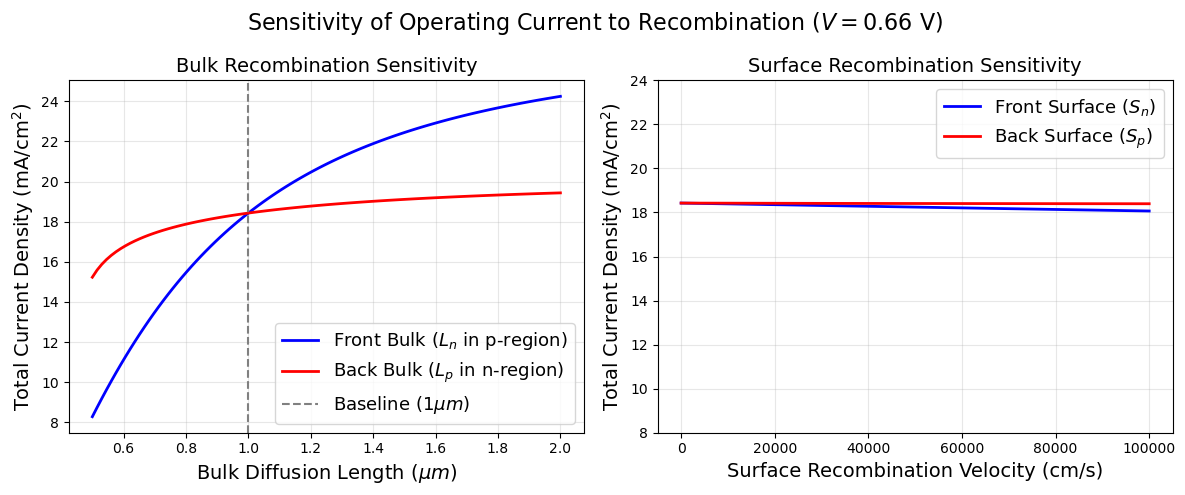

In [11]:
# Independent Parameter Sweeps & Plotting
L_baseline = 1e-4  # 1 um
S_baseline = 0.0

L_vals = np.linspace(0.5, 2, 100) * 1e-4  # 0.5 um to 2 um
S_vals = np.linspace(0, 1e5, 500)  # 0 to 100,000 cm/s

# Bulk Sweeps
J_Ln_sweep = [get_operating_current(L, L_baseline, S_baseline, S_baseline) for L in L_vals]
J_Lp_sweep = [get_operating_current(L_baseline, L, S_baseline, S_baseline) for L in L_vals]

# Surface Sweeps
J_Sn_sweep = [get_operating_current(L_baseline, L_baseline, S, S_baseline) for S in S_vals]
J_Sp_sweep = [get_operating_current(L_baseline, L_baseline, S_baseline, S) for S in S_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Sensitivity of Operating Current to Recombination ($V = 0.66$ V)", fontsize=16)

# Panel 1: Bulk Diffusion Lengths
ax1.plot(L_vals * 1e4, J_Ln_sweep, 'b-', lw=2, label=r'Front Bulk ($L_n$ in p-region)')
ax1.plot(L_vals * 1e4, J_Lp_sweep, 'r-', lw=2, label=r'Back Bulk ($L_p$ in n-region)')
ax1.axvline(1.0, color='gray', linestyle='--', label='Baseline ($1 \mu m$)')
ax1.set_xlabel(r'Bulk Diffusion Length ($\mu m$)', fontsize=14)
ax1.set_ylabel('Total Current Density (mA/cm$^2$)', fontsize=14)
ax1.set_title("Bulk Recombination Sensitivity", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=13)

# Panel 2: Surface Recombination
ax2.plot(S_vals, J_Sn_sweep, 'b-', lw=2, label=r'Front Surface ($S_n$)')
ax2.plot(S_vals, J_Sp_sweep, 'r-', lw=2, label=r'Back Surface ($S_p$)')
ax2.set_xlabel('Surface Recombination Velocity (cm/s)', fontsize=14)
ax2.set_ylabel('Total Current Density (mA/cm$^2$)', fontsize=14)
ax2.set_title("Surface Recombination Sensitivity", fontsize=14)
ax2.ticklabel_format(useOffset=False, style='plain') 
ax2.set_ylim(8, 24)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=13)

plt.tight_layout()
plt.show()

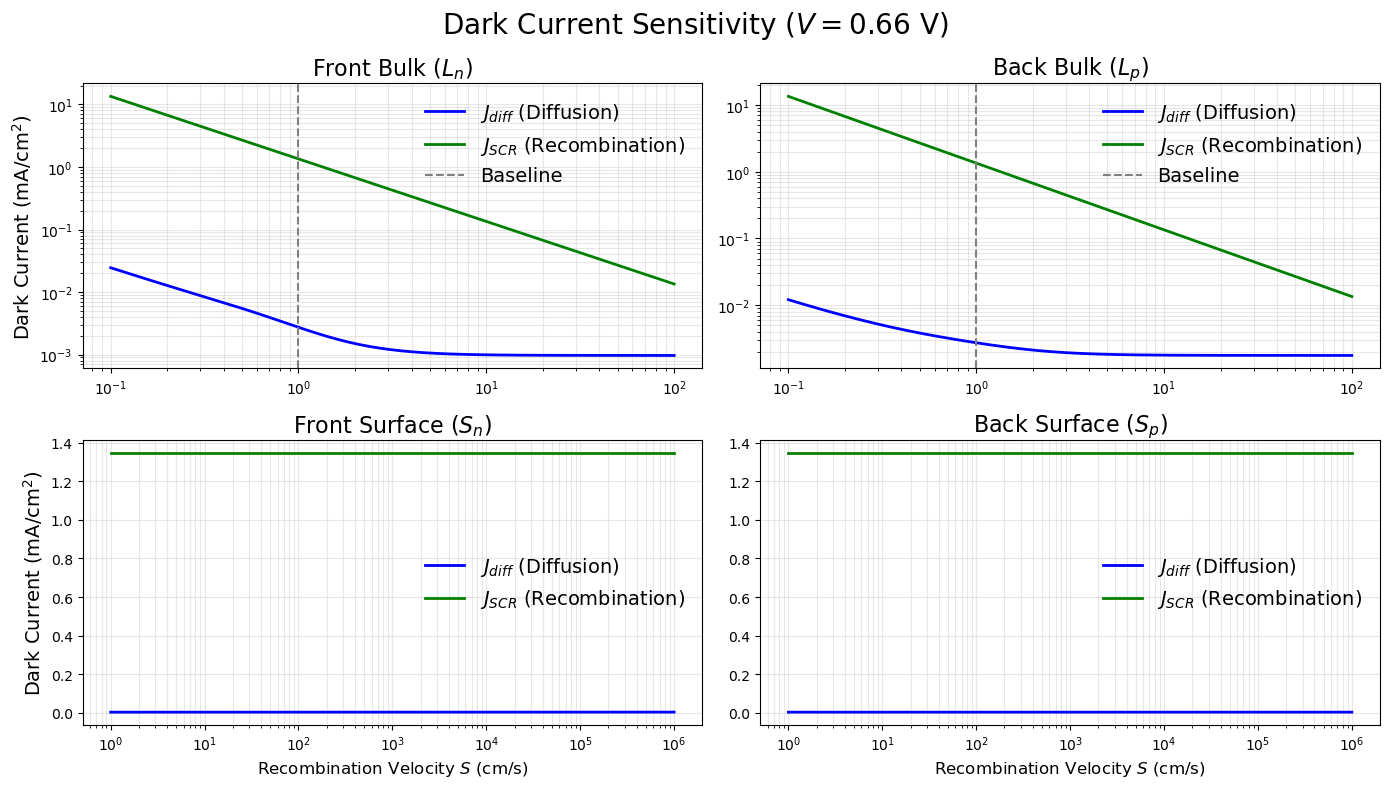

In [12]:
# Dark Current Sensitivity 

def get_dark_components_sensitivity(Ln, Lp, Sn, Sp, V=0.66):
    """Calculates J_diff and J_scr for specific recombination parameters."""
    Vbi = kT * np.log((Na * Nd) / ni**2)
    V_j = Vbi - V
    W = np.sqrt((2 * eps_s / q) * (1/Na + 1/Nd) * V_j)
    wp = W * (Nd / (Na + Nd))
    wn = W * (Na / (Na + Nd))
    
    # Diffusion Current
    n0 = ni**2 / Na
    up = (xp - wp) / Ln
    denom_n = (Sn*Ln/Dn)*np.sinh(up) + np.cosh(up)
    term2_n = n0 * (np.exp(V/kT) - 1) * ((Sn*Ln/Dn)*np.cosh(up) + np.sinh(up))
    Bn = -term2_n / denom_n
    J_n_wp = -q * Dn * (Bn / Ln) * 1000 
    
    p0 = ni**2 / Nd
    un = (xn - wn) / Lp
    denom_p = (Sp*Lp/Dp)*np.sinh(un) + np.cosh(un)
    term1_p = p0 * (np.exp(V/kT) - 1) * ((Sp*Lp/Dp)*np.cosh(un) + np.sinh(un))
    Bp = term1_p / denom_p
    J_p_wn = q * Dp * (Bp / Lp) * 1000 
    
    J_diff = abs(J_n_wp) + abs(J_p_wn)
    
    # SCR Recombination Current
    tau_n = (Ln**2) / Dn
    tau_p = (Lp**2) / Dp
    J_scr = ((q * ni * W) / np.sqrt(tau_n * tau_p)) * ((2 * np.sinh(V / (2*kT))) / (V_j / kT)) * (np.pi / 2) * 1000
    
    return J_diff, J_scr

# Parameter Sweeps (Logarithmic)
L_baseline = 1e-4  # 1 um
S_baseline = 0.0

L_vals_log = np.logspace(-5, -2, 200)  
S_vals_log = np.logspace(0, 6, 200)

J_diff_Ln, J_scr_Ln = [], []
J_diff_Lp, J_scr_Lp = [], []
J_diff_Sn, J_scr_Sn = [], []
J_diff_Sp, J_scr_Sp = [], []

# Sweep Ln (Front Bulk)
for L in L_vals_log:
    jd, js = get_dark_components_sensitivity(L, L_baseline, S_baseline, S_baseline, V=0.66)
    J_diff_Ln.append(jd)
    J_scr_Ln.append(js)

# Sweep Lp (Back Bulk)
for L in L_vals_log:
    jd, js = get_dark_components_sensitivity(L_baseline, L, S_baseline, S_baseline, V=0.66)
    J_diff_Lp.append(jd)
    J_scr_Lp.append(js)

# Sweep Sn (Front Surface)
for S in S_vals_log:
    jd, js = get_dark_components_sensitivity(L_baseline, L_baseline, S, S_baseline, V=0.66)
    J_diff_Sn.append(jd)
    J_scr_Sn.append(js)

# Sweep Sp (Back Surface)
for S in S_vals_log:
    jd, js = get_dark_components_sensitivity(L_baseline, L_baseline, S_baseline, S, V=0.66)
    J_diff_Sp.append(jd)
    J_scr_Sp.append(js)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Dark Current Sensitivity ($V = 0.66$ V)", fontsize=20)

# [0,0] Front Bulk Ln
axs[0,0].loglog(L_vals_log * 1e4, J_diff_Ln, 'b-', lw=2, label=r'$J_{diff}$ (Diffusion)')
axs[0,0].loglog(L_vals_log * 1e4, J_scr_Ln, 'g-', lw=2, label=r'$J_{SCR}$ (Recombination)')
axs[0,0].axvline(1.0, color='gray', linestyle='--', label='Baseline')
axs[0,0].set_title(r"Front Bulk ($L_n$)", fontsize=16)
axs[0,0].set_ylabel('Dark Current (mA/cm$^2$)', fontsize=14)

# [0,1] Back Bulk Lp
axs[0,1].loglog(L_vals_log * 1e4, J_diff_Lp, 'b-', lw=2, label=r'$J_{diff}$ (Diffusion)')
axs[0,1].loglog(L_vals_log * 1e4, J_scr_Lp, 'g-', lw=2, label=r'$J_{SCR}$ (Recombination)')
axs[0,1].axvline(1.0, color='gray', linestyle='--', label='Baseline')
axs[0,1].set_title(r"Back Bulk ($L_p$)", fontsize=16)

# [1,0] Front Surface Sn
axs[1,0].semilogx(S_vals_log, J_diff_Sn, 'b-', lw=2, label=r'$J_{diff}$ (Diffusion)')
axs[1,0].semilogx(S_vals_log, J_scr_Sn, 'g-', lw=2, label=r'$J_{SCR}$ (Recombination)')
axs[1,0].set_title(r"Front Surface ($S_n$)", fontsize=16)
axs[1,0].set_xlabel(r'Recombination Velocity $S$ (cm/s)', fontsize=12)
axs[1,0].set_ylabel('Dark Current (mA/cm$^2$)', fontsize=14)

# [1,1] Back Surface Sp
axs[1,1].semilogx(S_vals_log, J_diff_Sp, 'b-', lw=2, label=r'$J_{diff}$ (Diffusion)')
axs[1,1].semilogx(S_vals_log, J_scr_Sp, 'g-', lw=2, label=r'$J_{SCR}$ (Recombination)')
axs[1,1].set_title(r"Back Surface ($S_p$)", fontsize=16)
axs[1,1].set_xlabel(r'Recombination Velocity $S$ (cm/s)', fontsize=12)

for ax in axs.flat:
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=14, frameon=False)

plt.tight_layout()
plt.show()